## 1.Classifier

In [ ]:
import numpy as np

np.random.seed(42)


In [5]:
from sklearn.model_selection import cross_val_score
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import xgboost as xgb

X_class, y_class = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=15,
    n_redundant=5,
    n_classes=3,
    random_state=42,
)

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class, y_class, test_size=0.3, random_state=42
)

xgb_classifier = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0,  # Suppress output
)

xgb_classifier.fit(X_train_class, y_train_class)

y_pred_class = xgb_classifier.predict(X_test_class)
y_pred_proba = xgb_classifier.predict_proba(X_test_class)

accuracy = accuracy_score(y_test_class, y_pred_class)

# Cross-validation score
cv_scores = cross_val_score(xgb_classifier, X_class, y_class, cv=5)


In [7]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(f"Accuracy: {accuracy:.4f}")
print(
    f"Cross-validation accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})"
)
print(classification_report(y_test_class, y_pred_class))


Classification Report:
Accuracy: 0.8167
Cross-validation accuracy: 0.7930 (+/- 0.0665)
              precision    recall  f1-score   support

           0       0.81      0.81      0.81        99
           1       0.87      0.82      0.84       114
           2       0.77      0.83      0.80        87

    accuracy                           0.82       300
   macro avg       0.81      0.82      0.82       300
weighted avg       0.82      0.82      0.82       300



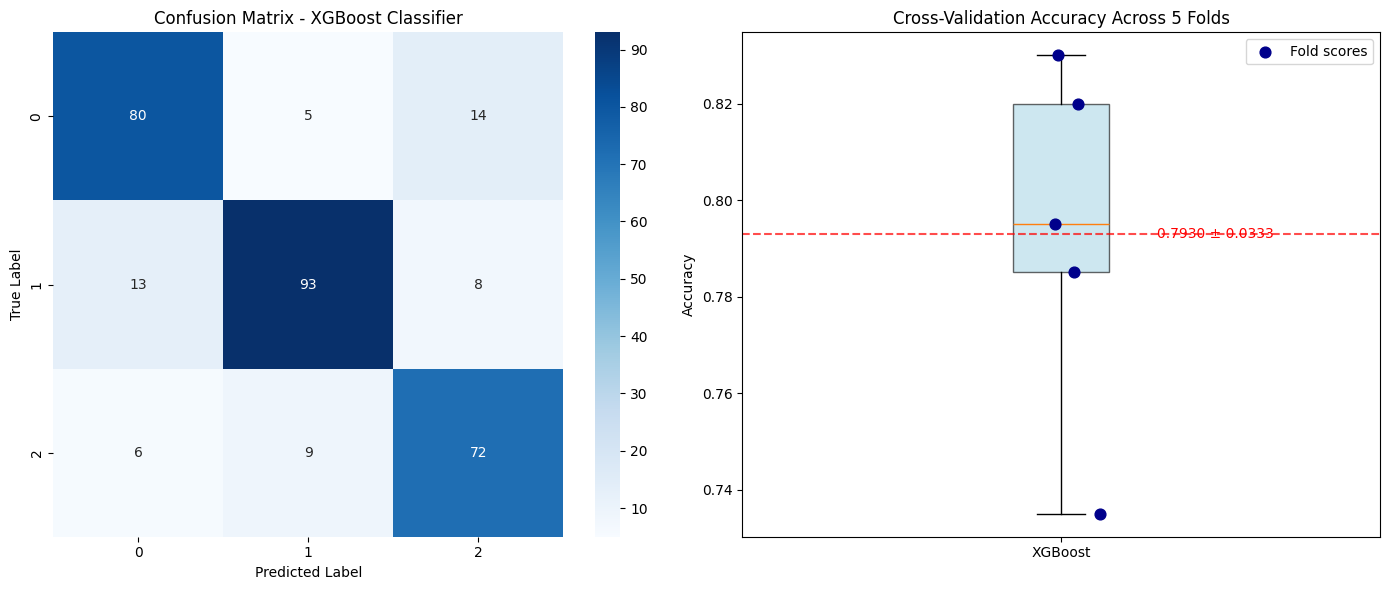

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Confusion Matrix
cm = confusion_matrix(y_test_class, y_pred_class)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(np.unique(y_class)),
    yticklabels=sorted(np.unique(y_class)),
    ax=axes[0],
)
axes[0].set_title("Confusion Matrix - XGBoost Classifier")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# 2. Cross-validation scores: boxplot + individual fold points
axes[1].boxplot(
    cv_scores,
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor="lightblue", alpha=0.6),
)

# Jitter the x-position slightly so points don't overlap in a single line
x_jitter = np.random.normal(1, 0.04, size=len(cv_scores))
axes[1].scatter(
    x_jitter, cv_scores, color="darkblue", zorder=3, s=60, label="Fold scores"
)

axes[1].set_title("Cross-Validation Accuracy Across 5 Folds")
axes[1].set_ylabel("Accuracy")
axes[1].set_xticks([1])
axes[1].set_xticklabels(["XGBoost"])
axes[1].legend()

# Optional: annotate mean and std on the plot
mean_score = cv_scores.mean()
std_score = cv_scores.std()
axes[1].axhline(
    mean_score, color="red", linestyle="--", alpha=0.7, label=f"Mean = {mean_score:.4f}"
)
axes[1].text(
    1.15, mean_score, f"{mean_score:.4f} ± {std_score:.4f}", color="red", va="center"
)

plt.tight_layout()
plt.show()


## 2.Regressor

In [2]:
from sklearn.datasets import make_regression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
import xgboost as xgb

X_reg, y_reg = make_regression(
    n_samples=1000, n_features=20, n_informative=15, noise=0.1, random_state=42
)


X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42
)


xgb_regressor = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0,
)





In [3]:
xgb_regressor.fit(X_train_reg, y_train_reg)

y_pred_reg = xgb_regressor.predict(X_test_reg)

from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

cv_scores_reg = cross_val_score(xgb_regressor, X_reg, y_reg, cv=5, scoring="r2")


In [ ]:
print("Regression Report:")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")
print(
    f"Cross-validation R²: {cv_scores_reg.mean():.4f} (+/- {cv_scores_reg.std() * 2:.4f})"
)


Regression Report:
Mean Squared Error: 9072.1826
R² Score: 0.8200
Cross-validation R²: 0.8173 (+/- 0.0328)


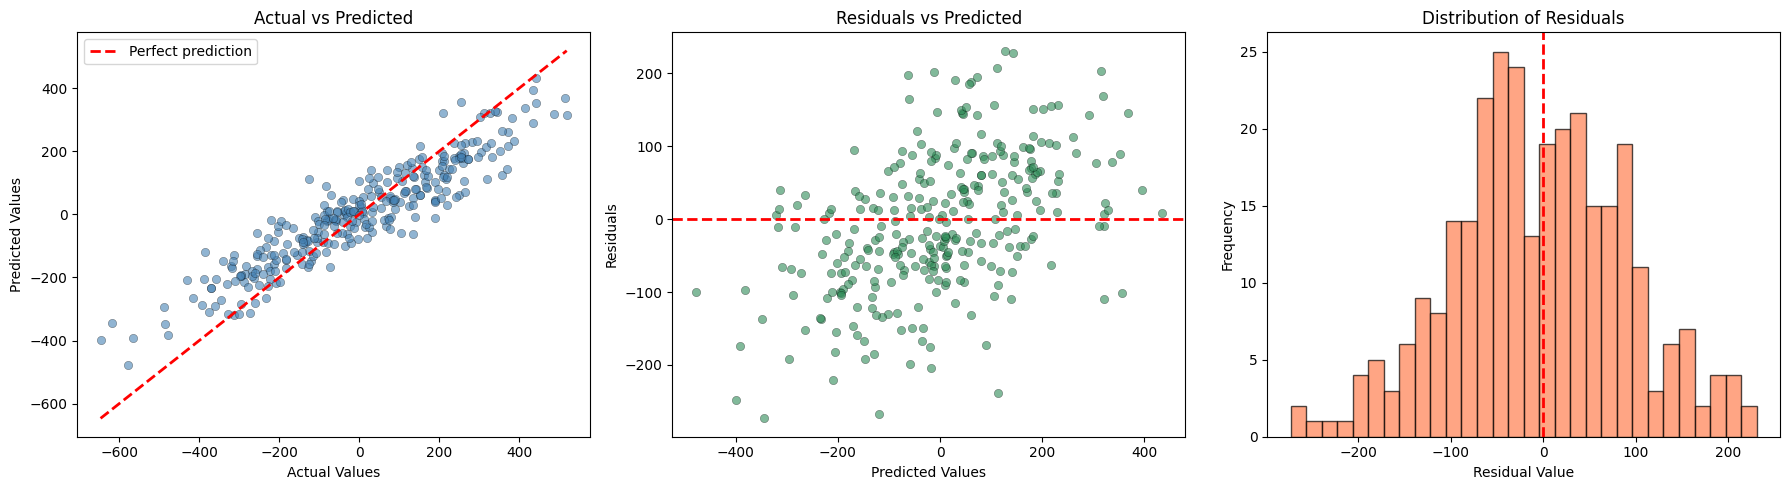

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

residuals = y_test_reg - y_pred_reg

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Actual vs Predicted
axes[0].scatter(
    y_test_reg, y_pred_reg, alpha=0.6, color="steelblue", edgecolor="k", linewidth=0.3
)
min_val = min(y_test_reg.min(), y_pred_reg.min())
max_val = max(y_test_reg.max(), y_pred_reg.max())
axes[0].plot(
    [min_val, max_val], [min_val, max_val], "r--", lw=2, label="Perfect prediction"
)
axes[0].set_xlabel("Actual Values")
axes[0].set_ylabel("Predicted Values")
axes[0].set_title("Actual vs Predicted")
axes[0].legend()

# 2. Residuals vs Predicted
axes[1].scatter(
    y_pred_reg, residuals, alpha=0.6, color="seagreen", edgecolor="k", linewidth=0.3
)
axes[1].axhline(y=0, color="red", linestyle="--", lw=2)
axes[1].set_xlabel("Predicted Values")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residuals vs Predicted")

# 3. Residuals distribution (histogram)
axes[2].hist(residuals, bins=30, color="coral", edgecolor="k", alpha=0.7)
axes[2].axvline(x=0, color="red", linestyle="--", lw=2)
axes[2].set_xlabel("Residual Value")
axes[2].set_ylabel("Frequency")
axes[2].set_title("Distribution of Residuals")

plt.tight_layout()
plt.show()


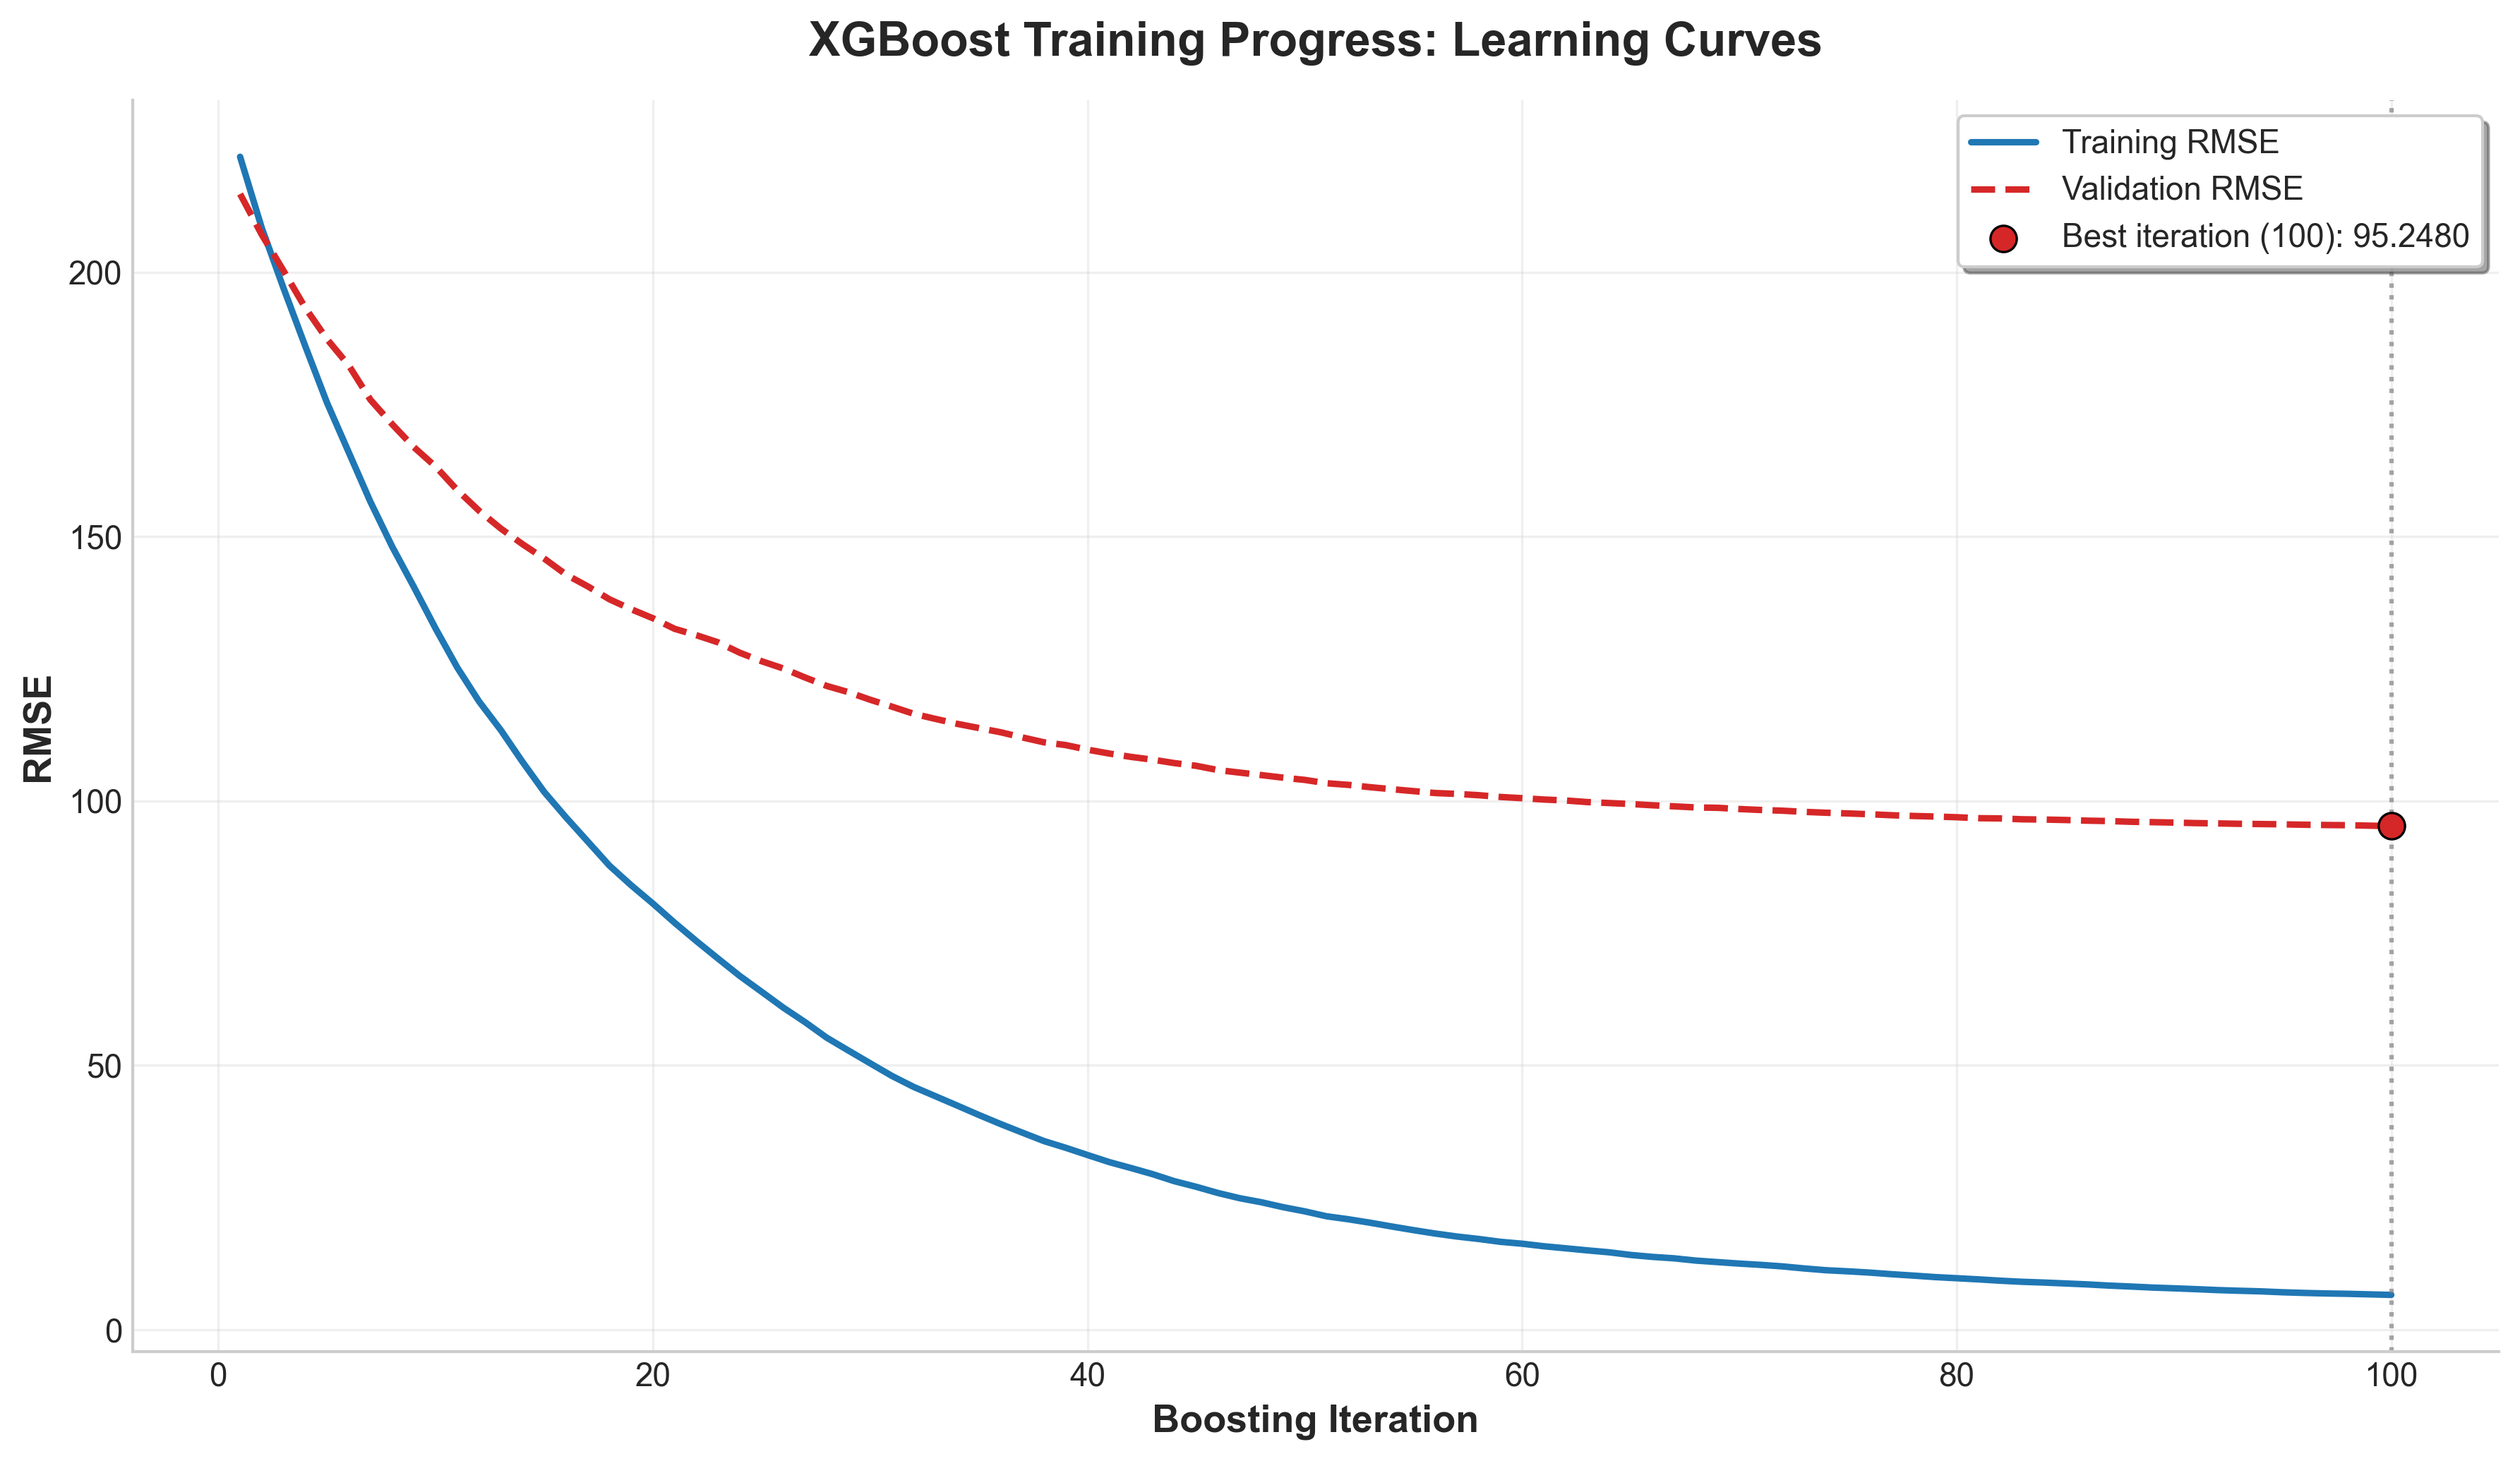

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Retrain with eval_set to capture per-iteration metrics
eval_set = [(X_train_reg, y_train_reg), (X_test_reg, y_test_reg)]

xgb_regressor_eval = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="rmse",  # or 'mae', 'logloss', 'mlogloss' for classifiers
    verbosity=0,
)

xgb_regressor_eval.fit(
    X_train_reg,
    y_train_reg,
    eval_set=eval_set,
    verbose=False,
)

# Extract the per-iteration metric history
results = xgb_regressor_eval.evals_result()
train_rmse = results["validation_0"]["rmse"]
val_rmse = results["validation_1"]["rmse"]
epochs = range(1, len(train_rmse) + 1)

# High-resolution, polished plot
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(12, 7), dpi=300)

ax.plot(epochs, train_rmse, label="Training RMSE", color="#1f77b4", linewidth=2.2)
ax.plot(
    epochs,
    val_rmse,
    label="Validation RMSE",
    color="#d62728",
    linewidth=2.2,
    linestyle="--",
)

# Mark the best iteration (lowest validation error)
best_iter = int(np.argmin(val_rmse))
ax.axvline(x=best_iter + 1, color="gray", linestyle=":", linewidth=1.5, alpha=0.7)
ax.scatter(
    [best_iter + 1],
    [val_rmse[best_iter]],
    color="#d62728",
    zorder=5,
    s=80,
    edgecolor="black",
    linewidth=0.8,
    label=f"Best iteration ({best_iter + 1}): {val_rmse[best_iter]:.4f}",
)

ax.set_xlabel("Boosting Iteration", fontsize=13, fontweight="bold")
ax.set_ylabel("RMSE", fontsize=13, fontweight="bold")
ax.set_title(
    "XGBoost Training Progress: Learning Curves", fontsize=16, fontweight="bold", pad=15
)
ax.legend(fontsize=11, frameon=True, shadow=True, loc="upper right")
ax.tick_params(labelsize=11)
ax.grid(True, alpha=0.3)

# Tight, clean borders
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("xgboost_learning_curve.png", dpi=300, bbox_inches="tight")
plt.show()
